`Today we will create oure own class Gradient Descent which will find the values of m and b for fitting and predicting the trained values`

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
# We will firstly make a random dataset with 1 input and 1 output columns
from sklearn.datasets import make_regression
X,y = make_regression(n_samples = 100, n_features = 1 , n_informative=1, n_targets = 1, noise = 20)

In [3]:
print(X.shape)
print(y.shape)

(100, 1)
(100,)


In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2)

In [6]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 1)
(20, 1)
(80,)
(20,)


In [28]:
class MeraGDRegressor:
    def __init__(self):

        self.m = int(input("Enter the first value for weightage 'm' :"))
        self.b = int(input("Enter the first value for intercept 'b' :"))
        self.learning_rate = float(input("Enter the first value for learning rate :"))
    def fit(self,X_train,y_train):
        for i in range(100):
            slope_m = -2 * np.sum((y_train - self.m * X_train.ravel() - self.b) * X_train.ravel())
            slope_b = -2 * np.sum(y_train - self.m * X_train.ravel() - self.b)
            self.m = self.m - self.learning_rate * slope_m
            self.b = self.b - self.learning_rate * slope_b
        print(self.m , self.b)
    def predict(self,X_test):
        y_pred = self.m * X_test + self.b
        return y_pred.ravel()

In [29]:
gd = MeraGDRegressor()

In [30]:
gd.fit(X_train,y_train)

47.634198273030634 0.9800448400893766


In [24]:
# To check if it is correct
lr = LinearRegression()

In [25]:
lr.fit(X_train,y_train)

LinearRegression()

In [26]:
print(lr.coef_[0])
print(lr.intercept_)

47.6341964964179
0.9800439262952425


`You can see that we got the exact values of weightage (m) and intercept (b)`

In [42]:
# Let us predict the values of X_test and then find MAE, RMSE and R2 score
y_pred = gd.predict(X_test)

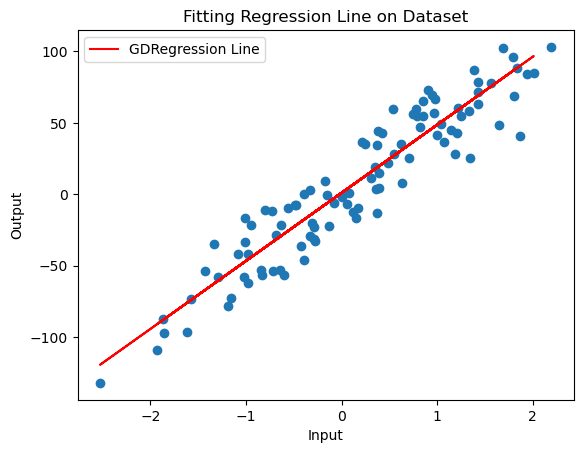

In [48]:
import matplotlib.pyplot as plt
plt.scatter(X,y)
plt.plot(X_train,gd.predict(X_train),color='red',label='GDRegression Line')
plt.legend()
plt.title("Fitting Regression Line on Dataset")
plt.xlabel("Input")
plt.ylabel("Output")
plt.show()

In [45]:
MAE = mean_squared_error(y_test,y_pred)
RMSE = root_mean_squared_error(y_test,y_pred)
r2_score = r2_score(y_test,y_pred)

In [46]:
print(f'Mean Squared Error -> {MAE}\nRoot Mean Squared Error -> {RMSE}\nR2 Score -> {r2_score}')

Mean Squared Error -> 303.2768624934274
Root Mean Squared Error -> 17.41484603702908
R2 Score -> 0.8698956641803305
